# Building a Knowledge Graph with LLMs


## Objective:

- Extract entities and relationships from text using an LLM.
- Store these entities and relationships in a graph database.
- Visualize the knowledge graph.


## Installing the required libraries


In [19]:
!pip install spacy pyvis

In [20]:
!python -m spacy download en_core_web_sm


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     -- ------------------------------------- 0.8/12.8 MB 4.8 MB/s eta 0:00:03
     ---- ----------------------------------- 1.6/12.8 MB 6.0 MB/s eta 0:00:02
     ----- ---------------------------------- 1.8/12.8 MB 3.2 MB/s eta 0:00:04
     ------- -------------------------------- 2.4/12.8 MB 2.7 MB/s eta 0:00:04
     ------- -------------------------------- 2.4/12.8 MB 2.7 MB/s eta 0:00:04
     --------- ------------------------------ 2.9/12.8 MB 2.4 MB/s eta 0:00:05
     ---------- ----------------------------- 3.4/12.8 MB 2.2 MB/s eta 0:00:05
     ---------- ----------------------------- 3.4/12.8 MB 2.2 MB/s eta 0:00:05
     ------------ --------------------------- 3.9/12.8 MB 2.0 MB/s eta 0:00:05
     ------------ --------------------------- 3.9/12.8 MB 2.0 MB/s eta 0:00:05
     ------------- -------------------------- 4.2/12.8 MB 1.9 MB/s

## Import necessary libraries


In [21]:
from openai import AsyncOpenAI

import networkx as nx
import matplotlib.pyplot as plt
from pyvis.network import Network
import re

## Sample text for knowledge graph extraction


In [22]:
text = """
Elon Musk is the CEO of Tesla and SpaceX. Tesla was founded by Martin Eberhard and Marc Tarpenning in 2003. 
SpaceX was founded by Elon Musk in 2002. Tesla's headquarters is in Palo Alto, while SpaceX is based in Hawthorne.
"""

## Load Spacy model for NER


In [23]:
nlp = spacy.load("en_core_web_sm")

## Extract entities using Spacy


In [24]:
def extract_entities(text):
    doc = nlp(text)
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    return entities

## Use OpenAI LLM to extract relationships


In [25]:
async def extract_relationships(text):
    """
    Extract relationships between entities using OpenAI GPT models.
    """
    prompt = f"""
        Extract relationships between entities from the following text:
        {text}

        Ensure to include temporal details like years and dates when they are relevant.
        Provide the output as a list of triples (entity1, relationship, entity2).
        """

    client = AsyncOpenAI()
    response = await client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {"role": "system", "content": "You are a helpful assistant that extracts relationships between entities."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.0,
        max_tokens=200
    )
    # Extract content and safely evaluate it as Python code
    # print(f"response is {response.choices[0].message.content}\n\n\n")
    output = response.choices[0].message.content
    return output  # Ensure input text is sanitized before using eval in production.

## Build and visualize the knowledge graph


In [26]:
def build_knowledge_graph(entities, relationships):
    """
    Build a knowledge graph using extracted entities and relationships.
    """
    G = nx.Graph()

    # Add nodes for entities
    for entity, label in entities:
        G.add_node(entity, label=label)

    # Add edges for relationships
    for entity1, relation, entity2 in relationships:
        G.add_edge(entity1, entity2, label=relation)

    return G


In [27]:
def visualize_graph(G):
    """
    Visualize the knowledge graph using Pyvis for an interactive experience.
    """
    net = Network(notebook=True)
    for node, attributes in G.nodes(data=True):
        net.add_node(node, title=attributes.get("label", node))
    for edge in G.edges(data=True):
        net.add_edge(edge[0], edge[1], title=edge[2].get("label", ""))
    return net


## Extract entities and relationships


In [28]:
entities = extract_entities(text)
relationships = await extract_relationships(text)

## Extract relationships to tuple format using regular expressions


In [29]:
pattern = r'\(\s*([^,]+)\s*,\s*([^,]+)\s*,\s*([^)]+)\s*\)'
matches = re.findall(pattern, relationships)
tuples = [tuple(match) for match in matches]

## Build the knowledge graph


In [30]:
G = build_knowledge_graph(entities, tuples)

# Visualize the graph
print(f"Entities: {entities}")
print(f"Relationships: {tuples}")

Entities: [('Elon Musk', 'PERSON'), ('Tesla', 'ORG'), ('Tesla', 'PERSON'), ('Martin Eberhard', 'PERSON'), ('Marc Tarpenning', 'PERSON'), ('2003', 'DATE'), ('SpaceX', 'PERSON'), ('Elon Musk', 'PERSON'), ('2002', 'DATE'), ('Tesla', 'ORG'), ('Palo Alto', 'GPE'), ('SpaceX', 'PERSON'), ('Hawthorne', 'GPE')]
Relationships: [('Elon Musk', 'CEO of', 'Tesla'), ('Elon Musk', 'CEO of', 'SpaceX'), ('Tesla', 'founded by', 'Martin Eberhard'), ('Tesla', 'founded by', 'Marc Tarpenning'), ('Tesla', 'founded in', '2003'), ('SpaceX', 'founded by', 'Elon Musk'), ('SpaceX', 'founded in', '2002'), ('Tesla', 'headquarters in', 'Palo Alto'), ('SpaceX', 'based in', 'Hawthorne')]


## Matplotlib Visualization


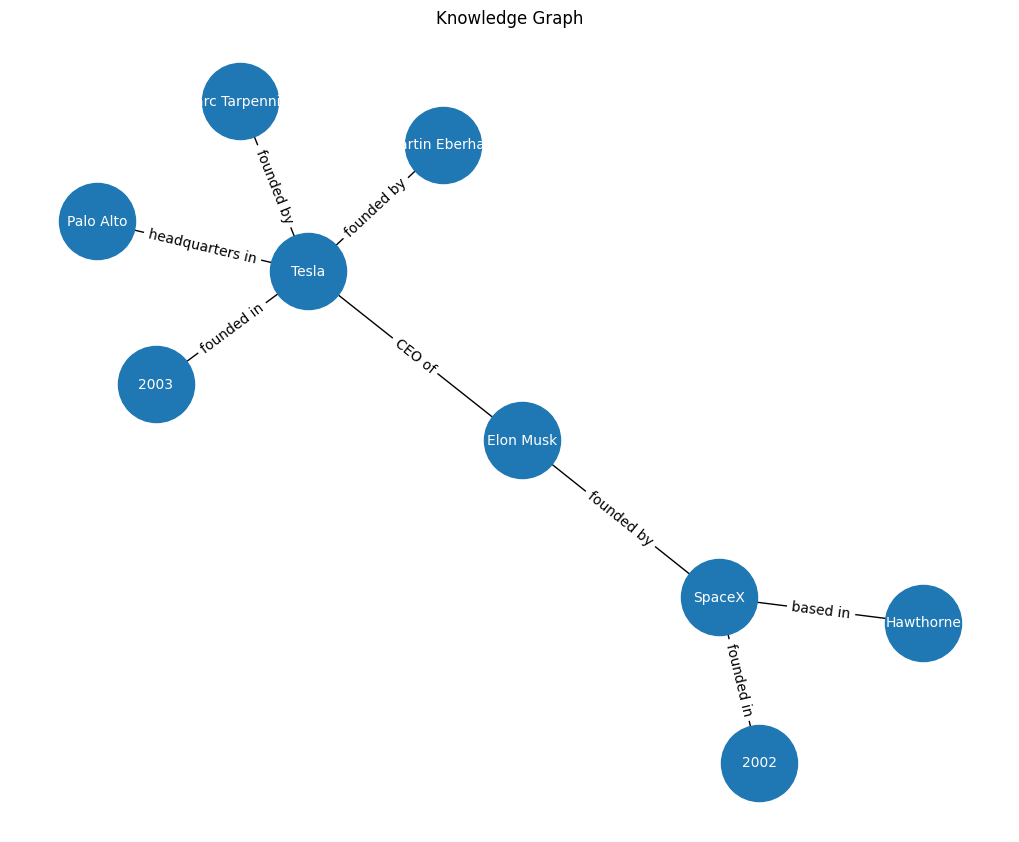

In [31]:
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=3000, font_size=10, font_color="white")
labels = nx.get_edge_attributes(G, "label")
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title("Knowledge Graph")
plt.show()

## Pyvis Interactive Visualization


In [32]:
net = visualize_graph(G)
net.show("knowledge_graph.html")

knowledge_graph.html
